<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Regression-based Rating Score Prediction using Embedding Features**


Estimated time needed: **45** minutes


In our previous lab, you have trained a neural network to predict the user-item interactions while simultaneously extracting the user and item embedding features. In the neural network, extends this by using  two embedding vectors as an input into a Neural Network to predict the rating.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/module_4/images/rating_regression.png)



Another way to make rating predictions is to use the embedding as an input to a neural network by aggregating them into a single feature vector as input data `X`. 

With the interaction label `Y` such as a rating score or an enrollment mode, we can build our other standalone predictive models to approximate the mapping from `X` to `Y`, as shown in the above flowchart.


In this lab, you will be given the course interaction feature vectors as input data `X` and consider label `Y` as the numerical rating scores. As such, we turn the recommender system into a common regression task and you can apply what you have learned about regression modeling to predict the ratings.


## Objectives


After completing this lab you will be able to:


* Build regression models to predict ratings using the combined embedding vectors


----


## Prepare and setup lab environment


First install and import required libraries:


In [2]:
%pip install scikit-learn
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.8 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 146.3 MB/s eta 0:00:00

Note: you may need to restart the kernel to use updated packages.

In [3]:
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

In [4]:
# also set a random state
rs = 123

In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

### Load datasets


In [6]:
rating_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"
user_emb_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_embeddings.csv"
item_emb_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_embeddings.csv"

The first dataset is the rating dataset that contains a user-item interaction matrix


In [7]:
rating_df = pd.read_csv(rating_url)

In [8]:
rating_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


As you can see from the above data, the user and item are just ids, let's substitute them by their embedding vectors:


In [9]:
# Load user embeddings
user_emb = pd.read_csv(user_emb_url)
# Load item embeddings
item_emb = pd.read_csv(item_emb_url)

In [10]:
user_emb.head()

,user,UFeature0,UFeature1,UFeature2,UFeature3,UFeature4,UFeature5,UFeature6,UFeature7,UFeature8,UFeature9,UFeature10,UFeature11,UFeature12,UFeature13,UFeature14,UFeature15
0,1889878,0.080721,-0.129561,0.087998,0.030231,0.082691,-0.004176,-0.003480,0.091464,-0.040247,0.018958,-0.153328,-0.090143,0.082830,-0.058721,0.057929,-0.001472
1,1342067,0.068047,-0.112781,0.045208,-0.007570,-0.038382,0.068037,0.114949,0.104128,-0.034401,0.004011,0.064832,0.165857,-0.004384,0.053257,0.014308,0.056684
2,1990814,0.124623,0.012910,-0.072627,0.049935,0.020158,0.133306,-0.035366,-0.156026,0.039269,0.042195,0.014695,-0.115989,0.031158,0.102021,-0.020601,0.116488
3,380098,-0.034870,0.000715,0.077406,0.070311,-0.043007,-0.035446,0.032846,-0.060944,0.112384,0.002114,0.090660,-0.068545,0.008967,0.063962,0.052347,0.018072
4,779563,0.106414,-0.001887,-0.017211,-0.042277,-0.074953,-0.056732,0.074610,-0.019367,-0.031341,0.064896,-0.048158,-0.047309,-0.007544,0.010474,-0.032287,-0.083983


In [11]:
item_emb.head()

,item,CFeature0,CFeature1,CFeature2,CFeature3,CFeature4,CFeature5,CFeature6,CFeature7,CFeature8,CFeature9,CFeature10,CFeature11,CFeature12,CFeature13,CFeature14,CFeature15
0,CC0101EN,0.009657,-0.005238,-0.004098,0.016303,-0.005274,-0.000361,-0.015081,-0.012229,0.015686,0.008401,-0.035495,0.009381,-0.032560,-0.007292,0.000966,-0.006218
1,CL0101EN,-0.008611,0.028041,0.021899,-0.001465,0.006900,-0.017981,0.010899,-0.037610,-0.019397,-0.025682,-0.000620,0.038803,0.000196,-0.045343,0.012863,0.019429
2,ML0120ENv3,0.027439,-0.027649,-0.007484,-0.059451,0.003972,0.020496,-0.012695,0.036138,0.019965,0.018686,-0.010450,-0.050011,0.013845,-0.044454,-0.001480,-0.007559
3,BD0211EN,0.020163,-0.011972,-0.003714,-0.015548,-0.007540,0.014847,-0.005700,-0.006068,-0.005792,-0.023036,0.015999,-0.023480,0.015469,0.022221,-0.023115,-0.001785
4,DS0101EN,0.006399,0.000492,0.005640,0.009639,-0.005487,-0.000590,-0.010015,-0.001514,-0.017598,0.003590,0.016799,0.002732,0.005162,0.015031,-0.000877,-0.021283


In [12]:
# Merge user embedding features
user_emb_merged = pd.merge(rating_df, user_emb, how='left', left_on='user', right_on='user').fillna(0)
# Merge course embedding features
merged_df = pd.merge(user_emb_merged, item_emb, how='left', left_on='item', right_on='item').fillna(0)

In [13]:
merged_df.head()

,user,item,rating,UFeature0,UFeature1,UFeature2,UFeature3,UFeature4,UFeature5,UFeature6,...,CFeature6,CFeature7,CFeature8,CFeature9,CFeature10,CFeature11,CFeature12,CFeature13,CFeature14,CFeature15
0,1889878,CC0101EN,5,0.080721,-0.129561,0.087998,0.030231,0.082691,-0.004176,-0.003480,...,-0.015081,-0.012229,0.015686,0.008401,-0.035495,0.009381,-0.032560,-0.007292,0.000966,-0.006218
1,1342067,CL0101EN,3,0.068047,-0.112781,0.045208,-0.007570,-0.038382,0.068037,0.114949,...,0.010899,-0.037610,-0.019397,-0.025682,-0.000620,0.038803,0.000196,-0.045343,0.012863,0.019429
2,1990814,ML0120ENv3,5,0.124623,0.012910,-0.072627,0.049935,0.020158,0.133306,-0.035366,...,-0.012695,0.036138,0.019965,0.018686,-0.010450,-0.050011,0.013845,-0.044454,-0.001480,-0.007559
3,380098,BD0211EN,5,-0.034870,0.000715,0.077406,0.070311,-0.043007,-0.035446,0.032846,...,-0.005700,-0.006068,-0.005792,-0.023036,0.015999,-0.023480,0.015469,0.022221,-0.023115,-0.001785
4,779563,DS0101EN,3,0.106414,-0.001887,-0.017211,-0.042277,-0.074953,-0.056732,0.074610,...,-0.010015,-0.001514,-0.017598,0.003590,0.016799,0.002732,0.005162,0.015031,-0.000877,-0.021283


Next, we can combine the user features (the column labels starting with `UFeature` and item features (the column labels starting with `CFeature`. In machine learning, there are many ways to aggregate two feature vectors such as element-wise add, multiply, max/min, average, etc. Here we simply add the two sets of feature columns:


In [14]:
# Define column names for user and course embedding features
u_features = [f"UFeature{i}" for i in range(16)] # Assuming there are 16 user embedding features
c_features = [f"CFeature{i}" for i in range(16)]  # Assuming there are 16 course embedding features

# Extract user embedding features
user_embeddings = merged_df[u_features]
# Extract course embedding features
course_embeddings = merged_df[c_features]
# Extract ratings
ratings = merged_df['rating']

# Aggregate the two feature columns using element-wise add
regression_dataset = user_embeddings + course_embeddings.values
# Rename the columns of the resulting DataFrame
regression_dataset.columns = [f"Feature{i}" for i in range(16)]# Assuming there are 16 features
# Add the 'rating' column from the original DataFrame to the regression dataset
regression_dataset['rating'] = ratings
# Display the first few rows of the regression dataset
regression_dataset.head()

,Feature0,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,Feature11,Feature12,Feature13,Feature14,Feature15,rating
0,0.090378,-0.134799,0.083900,0.046534,0.077417,-0.004537,-0.018561,0.079236,-0.024561,0.027359,-0.188823,-0.080762,0.050271,-0.066013,0.058894,-0.007689,5
1,0.059437,-0.084740,0.067107,-0.009036,-0.031482,0.050057,0.125847,0.066517,-0.053798,-0.021671,0.064212,0.204660,-0.004188,0.007914,0.027170,0.076114,3
2,0.152061,-0.014739,-0.080112,-0.009516,0.024130,0.153802,-0.048061,-0.119888,0.059234,0.060882,0.004244,-0.166000,0.045002,0.057566,-0.022081,0.108929,5
3,-0.014707,-0.011257,0.073692,0.054763,-0.050547,-0.020599,0.027146,-0.067012,0.106593,-0.020921,0.106658,-0.092025,0.024436,0.086183,0.029232,0.016287,5
4,0.112812,-0.001395,-0.011572,-0.032638,-0.080440,-0.057321,0.064595,-0.020880,-0.048939,0.068486,-0.031359,-0.044577,-0.002381,0.025505,-0.033164,-0.105266,3


By now, we have built the input dataset `X` and the output vector `y`:


In [15]:
X = regression_dataset.iloc[:, :-1]
y = regression_dataset.iloc[:, -1]
print(f"Input data shape: {X.shape}, Output data shape: {y.shape}")

Input data shape: (233306, 16), Output data shape: (233306,)

## TASK: Perform regression on the interaction dataset


Now our input data `X` and output `y` are ready, let's build regression models to map X to y and predict ratings. 


y.unique()


You may use `sklearn` to train and evaluate various regression models.


_TODO: First split dataset into training and testing datasets_


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=rs
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training output shape: {y_train.shape}")
print(f"Testing output shape: {y_test.shape}")


Training data shape: (163314, 16)
Testing data shape: (69992, 16)
Training output shape: (163314,)
Testing output shape: (69992,)

<details>
    <summary>Click here for Hints</summary>
    
Use `train_test_split()` to split dataset into training and testing datasets.  Use `X, y` as input dataset and output vector. Don't forget to specify `random_state = rs` and `test_size=0.3`.


_TODO: Create a basic linear regression model_


In [18]:
from sklearn.linear_model import LinearRegression
linear_regression = LinearRegression()


<details>
    <summary>Click here for Hints</summary>
    
You can call `linear_regression = LinearRegression()` method to create a Linear Regression object


_TODO: Train the basic regression model with training data_


In [19]:
linear_regression.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-0.04, 0.01, 0.03,..., 0.03, 0.01, 0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['Feature0','Feature1','Feature2',...,'Feature13','Feature14','Feature15']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.997
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


<details>
    <summary>Click here for Hints</summary>
    
You can call `model.fit()` method with `X_train, y_train` parameters.


_TODO: Evaluate the basic regression model_


In [21]:
import numpy as np
y_pred = linear_regression.predict(X_test)

# Calculate RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 0.8138346209967071

<details>
    <summary>Click here for Hints</summary>
    
You can call `model.predict()` method with `X_test` parameter to get model predictions. Then use `mean_squared_error()` with `y_test, your_predictions` parameters to calculate the RMSE. 


_TODO: Try different regression models such as Ridge, Lasso, ElasticNet and tune their hyperparameters to see which one has the best performance_


In [22]:
# Importing required models and metrics
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [23]:
#Ride ge regression using grid search for optimal hyperparameter
ridge = Ridge()
ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}
ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring="neg_mean_squared_error"
)
ridge_grid.fit(X_train, y_train)
ridge_pred = ridge_grid.predict(X_test)
ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)
print("Best Ridge alpha:", ridge_grid.best_params_)
print("Ridge RMSE:", ridge_rmse)

Best Ridge alpha: {'alpha': 100}
Ridge RMSE: 0.813829831172954

In [24]:
#Lasso Regression with grid search to find optimal hyperparameter
lasso = Lasso(max_iter=10000)
lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}
lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring="neg_mean_squared_error"
)
lasso_grid.fit(X_train, y_train)
lasso_pred = lasso_grid.predict(X_test)
lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_pred)
)
print("Best Lasso alpha:", lasso_grid.best_params_)
print("Lasso RMSE:", lasso_rmse)

Best Lasso alpha: {'alpha': 0.001}
Lasso RMSE: 0.8138177875012098

In [25]:
# ElasticNet Regression
# ElasticNet has two important hyperparameters:
'''
alpha — controls the overall regularization
l1_ratio — controls the balance between Lasso and Ridge regularization'''
elastic = ElasticNet(max_iter=10000)
elastic_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1],
    "l1_ratio": [0.1, 0.5, 0.9]
}
elastic_grid = GridSearchCV(
    elastic,
    elastic_params,
    cv=5,
    scoring="neg_mean_squared_error"
)
elastic_grid.fit(X_train, y_train)
elastic_pred = elastic_grid.predict(X_test)
elastic_rmse = np.sqrt(
    mean_squared_error(y_test, elastic_pred)
)
print("Best ElasticNet parameters:", elastic_grid.best_params_)
print("ElasticNet RMSE:", elastic_rmse)

Best ElasticNet parameters: {'alpha': 0.001, 'l1_ratio': 0.5}
ElasticNet RMSE: 0.8138177875012098

In [26]:
# Comparing all 3 models
print("\nModel Performance")
print("---------------------------")
print("Linear Regression RMSE:", rmse)
print("Ridge RMSE:", ridge_rmse)
print("Lasso RMSE:", lasso_rmse)
print("ElasticNet RMSE:", elastic_rmse)


Model Performance
---------------------------
Linear Regression RMSE: 0.8138346209967071
Ridge RMSE: 0.813829831172954
Lasso RMSE: 0.8138177875012098
ElasticNet RMSE: 0.8138177875012098

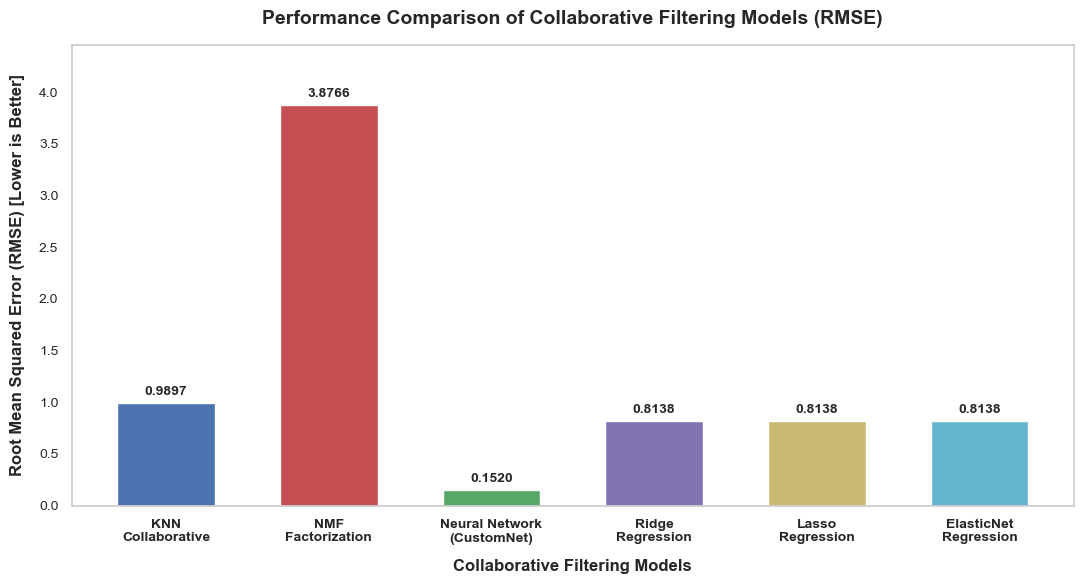

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Model names and their corresponding test RMSE results
models = [
    'KNN\nCollaborative',
    'NMF\nFactorization',
    'Neural Network\n(CustomNet)',
    'Ridge\nRegression',
    'Lasso\nRegression',
    'ElasticNet\nRegression',
]

rmse_scores = [0.9897, 3.8766, 0.1520, 0.8138, 0.8138, 0.8138]

# Set visual style
sns.set_theme(style='whitegrid')
plt.figure(figsize=(11, 6))

# Create vertical bar chart (Models on X-axis, RMSE on Y-axis)
bars = plt.bar(
    models, 
    rmse_scores, 
    color=['#4C72B0', '#C44E52', '#55A868', '#8172B2', '#CCB974', '#64B5CD'],
    width=0.6
)

# Add exact RMSE values on top of each bar
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      height + 0.05,
      f'{height:.4f}',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
  )

# Labels, title, and formatting
plt.xlabel('Collaborative Filtering Models', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Root Mean Squared Error (RMSE) [Lower is Better]', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Performance Comparison of Collaborative Filtering Models (RMSE)', fontsize=14, fontweight='bold', pad=15)

# Adjust y-axis limits to give space for text labels on top of bars
plt.ylim(0, max(rmse_scores) * 1.15)

# Rotate x-axis labels slightly for clean presentation
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(visible=None)

plt.tight_layout()
plt.show()

### Summary


In this lab, you have built regression models to predict numerical course ratings using the embedding feature vectors extracted from neural networks. In the next lab, we can treat the prediction problem as a classification problem as rating only has two categorical values so classification can be a more natural problem statement.


## Authors


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/)


### Other Contributors


```toggle## Change Log
```


```toggle|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
```
```toggle|-|-|-|-|
```
```toggle|2021-10-25|1.0|Yan|Created the initial version|
```


Copyright © 2021 IBM Corporation. All rights reserved.
